# Part 0: Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

from art.estimators.classification import KerasClassifier
from art.attacks.evasion import FastGradientMethod, CarliniLInfMethod, CarliniL2Method , ProjectedGradientDescentTensorFlowV2, AutoProjectedGradientDescent,ProjectedGradientDescent

print(tf.__version__)

2026-04-27 21:27:13.333244: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 21:27:13.333485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 21:27:13.366293: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 21:27:14.284225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

2.20.0


# Part 1 : Building a Model

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

category_loss_from_logits = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='linear')
])

model.compile(optimizer='adam',
              loss=category_loss_from_logits,
              metrics=['accuracy']);

2026-04-27 21:27:15.371048: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
model.fit(x_train, y_train, epochs=5);

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9160 - loss: 0.2913
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9578 - loss: 0.1436
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9676 - loss: 0.1083   
Epoch 4/5
 175/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9745 - loss: 0.0846

In [ ]:
loss_test, accuracy_test = model.evaluate(x_test, y_test)
print('Accuracy on test data: {:4.2f}%'.format(accuracy_test * 100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - accuracy: 0.9756 - loss: 0.0778
Accuracy on test data: 97.56%


In [ ]:
#1/ Train for 5 epochs a model called "model1" that has only one hidden layer of 64 neurons and only *linear* activations instead of ReLU;
#compare its accuracy with the first model


model1 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(64, activation='linear'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='linear')
])
model1.compile(optimizer='adam',
              loss=category_loss_from_logits,
              metrics=['accuracy']);

model1.fit(x_train,y_train, epochs=5);


loss_test, accuracy_test = model1.evaluate(x_test, y_test)
print('Accuracy on test data: {:4.2f}%'.format(accuracy_test * 100))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - accuracy: 0.8852 - loss: 0.3978
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - accuracy: 0.9110 - loss: 0.3179
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step - accuracy: 0.9131 - loss: 0.3069
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - accuracy: 0.9160 - loss: 0.3018
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9173 - loss: 0.2934
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.9192 - loss: 0.2865
Accuracy on test data: 91.92%


In [ ]:
#2/ Train for 5 epochs a model called "model2" that has 5 dense layer of 128 neurons and a relu activation and no dropout; compare its accuracy with the first model

model2 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='linear')
])

model2.compile(optimizer='adam',
              loss=category_loss_from_logits,
              metrics=['accuracy']);

model2.fit(x_train, y_train, epochs=5);
loss_test, accuracy_test = model2.evaluate(x_test, y_test)
print('Accuracy on test data: {:4.2f}%'.format(accuracy_test * 100))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9237 - loss: 0.2520
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9646 - loss: 0.1187
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9739 - loss: 0.0870
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9788 - loss: 0.0716
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9816 - loss: 0.0591
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - accuracy: 0.9753 - loss: 0.0922
Accuracy on test data: 97.53%


In [ ]:
#2bis/ (OPTIONAL CHALLENGE /!\) Train for 5 epochs a "model3" that obtains more 99% of accuracy on *test* data (hint: you might want to use 2D convolutional layers,i.e. tf.keras.layers.Conv2D(...), and MaxPool layers, i.e.  tf.keras.layers.MaxPooling2D(...))

X_train, Y_train = np.reshape(x_train, (*x_train.shape, 1)), np.reshape(y_train, (*y_train.shape, 1))
X_test, Y_test = np.reshape(x_test, (*x_test.shape, 1)), np.reshape(y_test, (*y_test.shape, 1))

model3 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,  activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='linear')
])

model3.compile(optimizer='adam',
            loss=category_loss_from_logits,
            metrics=['accuracy']);

model3.fit(X_train, Y_train, epochs=5)
loss_test, accuracy_test = model3.evaluate(X_test, Y_test)
print('Accuracy on test data: {:4.2f}%'.format(accuracy_test * 100))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9573 - loss: 0.1392
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9859 - loss: 0.0461
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9892 - loss: 0.0324
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9924 - loss: 0.0230
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9944 - loss: 0.0174
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0276
Accuracy on test data: 99.16%


# Part 2: Simple Whitebox Adversarial Attacks

In [ ]:
classifier = KerasClassifier(model=model, clip_values=(0, 1), use_logits=True, )
x_test = x_test[0:100]
y_test = y_test[0:100]

## FGSM attacks

In [ ]:
attack_fgsm = FastGradientMethod(estimator=classifier, eps=16/255, norm=np.inf)

In [ ]:
x_test_adv = attack_fgsm.generate(x_test)

In [ ]:
loss_test, accuracy_test = model.evaluate(x_test_adv, y_test)
perturbation = np.mean(np.abs((x_test_adv - x_test)))

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5400 - loss: 1.2473 
Accuracy on adversarial test data: 54.00%
Average perturbation: 0.04


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
predicted class of original image: 7


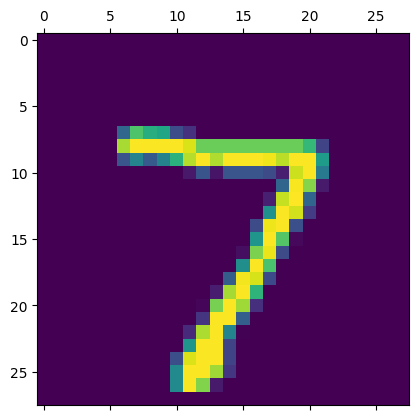

In [ ]:
y_pred_0 = model.predict(x_test[0:1])
print(f"predicted class of original image: {y_pred_0.argmax()}")
plt.matshow(x_test[0])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
predicted class of adversarial attack: 7


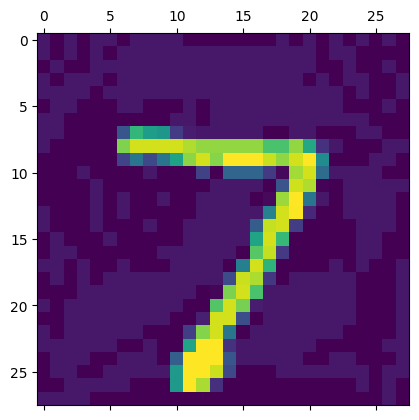

In [ ]:
y_pred_0 = model.predict(x_test_adv[0:1])
print(f"predicted class of adversarial attack: {y_pred_0.argmax()}")
plt.matshow(x_test_adv[0])
plt.show()

In [ ]:
#3/ Run an FGSM attack on the norm Inf and 2 with EQUIVALENT epsilons, e.g. eps=4/255 for the norm Inf and eps=(16/255)*sqrt(784) for the l2 norm. Display the results. Which one leads to the best image?

attack_fgsm_linf = FastGradientMethod(
    estimator=classifier,
    norm=np.inf,
    eps=4/255
)

x_test_adv_linf = attack_fgsm_linf.generate(x_test)

loss_test, accuracy_test = model.evaluate(x_test_adv_linf, y_test)
perturbation = np.mean(np.abs(x_test_adv_linf - x_test))

print('Linf FGSM')
print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.5f}'.format(perturbation))

y_pred_0 = model.predict(x_test_adv_linf[0:1])
print(f"predicted class of adversarial attack: {y_pred_0.argmax()}")

plt.matshow(x_test_adv_linf[0])
plt.title("FGSM Linf")
plt.show()

NameError: name 'FastGradientMethod' is not defined

In [ ]:
#3/ Run an FGSM attack on the norm Inf and 2 with EQUIVALENT epsilons, e.g. eps=16/255 for the norm Inf and eps=(16/255)*sqrt(784) for the l2 norm. Display the results. Which one leads to the best image?

attack_fgsm = FastGradientMethod(
    estimator=classifier,
    norm=2,
    eps=(16/255) * np.sqrt(784)
)
x_test_adv = attack_fgsm.generate(x_test)

loss_test, accuracy_test = model.evaluate(x_test_adv, y_test)
perturbation = np.mean(np.abs((x_test_adv - x_test)))

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.5f}'.format(perturbation))
y_pred_0 = model.predict(x_test_adv[0:1])
print(f"predicted class of adversarial attack: {y_pred_0.argmax()}")
plt.matshow(x_test_adv[0])
plt.show()

NameError: name 'FastGradientMethod' is not defined

# Part 3: Other Adversarial Attacks (Carlini-Wagner, APGD...)

In [ ]:
attack_cw = CarliniL2Method(classifier=classifier,
                              max_iter=20,
                              learning_rate=0.01,
                              initial_const=1e0,
                              )

In [ ]:
x_test_adv_cw = attack_cw.generate(x_test[:10]) #I have used CPU and have to limit the number of samples for the attack for the time of the attack

C&W L_2:   0%|          | 0/10 [00:00<?, ?it/s]

C&W L_2: 100%|██████████| 10/10 [04:15<00:00, 25.56s/it]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted class: 3
L2 dist to original image 3.15


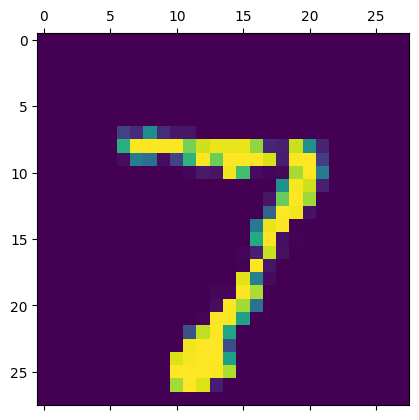

In [ ]:
idx = 0
plt.matshow(x_test_adv_cw[idx])
y_pred_adv_cw = model.predict(x_test_adv_cw[idx:idx+1])
print(f"Predicted class: {y_pred_adv_cw.argmax()}")
print(f"L2 dist to original image {np.linalg.norm(x_test_adv_cw[idx] - x_test[idx],):.2f}")
plt.show()

In [ ]:
loss_test, accuracy_test = model.evaluate(x_test_adv_cw, y_test[:10])

perturbation = np.mean(np.abs(x_test_adv_cw - x_test[:10]))

l_2_perturbation = np.linalg.norm(
    x_test_adv_cw - x_test[:10],
    axis=(1, 2)
)

l_2_perturbation_mean_cw = np.mean(l_2_perturbation)

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))
print('Average l2 perturbation: {:4.2f}'.format(l_2_perturbation_mean_cw))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 0.9948
Accuracy on adversarial test data: 0.00%
Average perturbation: 0.03
Average l2 perturbation: 2.80


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0700 - loss: 5.9778 
Accuracy on adversarial test data: 7.00%
Average perturbation: 0.05
Average l2 perturbation: 2.25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted class: 3
L2 dist to original image 2.19


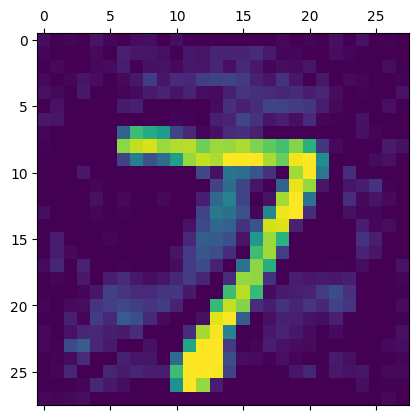

In [ ]:
#4/ Generate a new FGSM attack with the same l2 perturbation as the previous CW and compare their effectiveness: i.e. %of success for similar average l2 perturbation

eps = l_2_perturbation_mean_cw

attack_fgsm = FastGradientMethod(
    estimator=classifier,
    norm=2,
    eps=eps
)

x_test_adv = attack_fgsm.generate(x_test)

loss_test, accuracy_test = model.evaluate(x_test_adv, y_test)

perturbation = np.mean(np.abs(x_test_adv - x_test))

l_2_perturbation = np.linalg.norm(
    x_test_adv - x_test,
    axis=(1, 2)
)

l_2_perturbation_mean = np.mean(l_2_perturbation)

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))
print('Average l2 perturbation: {:4.2f}'.format(l_2_perturbation_mean))

idx = 0
plt.matshow(x_test_adv[idx])
y_pred_adv = model.predict(x_test_adv[idx:idx+1])
print(f"Predicted class: {y_pred_adv.argmax()}")
print(f"L2 dist to original image {np.linalg.norm(x_test_adv[idx] - x_test[idx]):.2f}")
plt.show()

AutoPGD - restart:   0%|          | 0/1 [00:00<?, ?it/s]























AutoPGD - restart: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3750 - loss: 2.3622

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3900 - loss: 2.2087 
Accuracy on adversarial test data: 39.00%
Average perturbation: 0.05
Average l2 perturbation: 2.22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted class: 3
L2 dist to original image 2.27


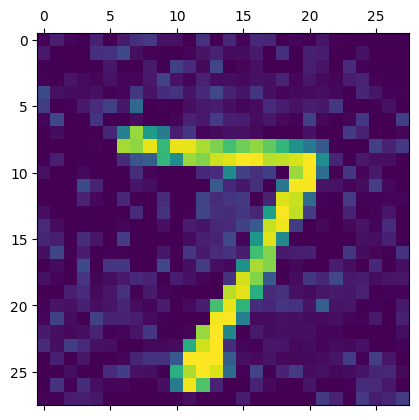

In [ ]:
#5/ Generate a new APGD attack (class AutoProjectedGradientDescent) with the same (or lower) average l2 perturbation as the previous CW and FGSM, and compare their effectiveness
# to limit computation time you can set 'max_iter=10' and "nb_random_init=1", in the function arguments
eps = l_2_perturbation_mean_cw

attack_apgd = AutoProjectedGradientDescent(
    estimator=classifier,
    norm=2,
    eps=eps,
    max_iter=10,
    nb_random_init=1
)

x_test_adv_apgd = attack_apgd.generate(x_test)

loss_test, accuracy_test = model.evaluate(x_test_adv_apgd, y_test)

perturbation = np.mean(np.abs(x_test_adv_apgd - x_test))

l_2_perturbation = np.linalg.norm(
    x_test_adv_apgd - x_test,
    axis=(1, 2)
)

l_2_perturbation_mean = np.mean(l_2_perturbation)

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))
print('Average l2 perturbation: {:4.2f}'.format(l_2_perturbation_mean))

idx = 0
plt.matshow(x_test_adv_apgd[idx])
y_pred_adv_apgd = model.predict(x_test_adv_apgd[idx:idx+1])
print(f"Predicted class: {y_pred_adv_apgd.argmax()}")
print(f"L2 dist to original image {np.linalg.norm(x_test_adv_apgd[idx] - x_test[idx]):.2f}")
plt.show()

PGD - Random Initializations: 100%|██████████| 5/5 [00:00<00:00,  8.76it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0200 - loss: 12.4653 


Accuracy on adversarial test data: 2.00%
Average perturbation: 0.05
Average l2 perturbation: 2.24
Attack success rate: 98.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted class: 3
L2 dist to original image 2.24


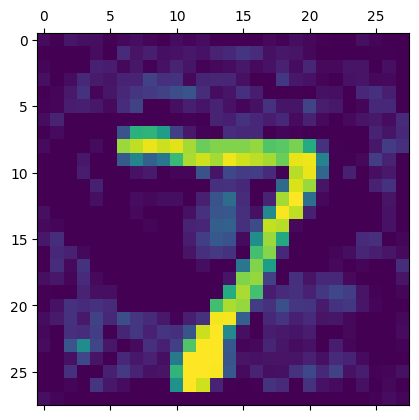

In [ ]:
#5bis/ /!\ OPTIONAL CHALLENGE: find an adversarial attack in the same library (https://adversarial-robustness-toolbox.readthedocs.io/en/latest/modules/attacks/evasion.html)
#having better results with the SAME l2 perturbation

eps = l_2_perturbation_mean_cw*0.8

attack_pgd = ProjectedGradientDescent(
    estimator=classifier,
    norm=2,
    eps=eps,
    eps_step=eps / 10,
    max_iter=40,
    num_random_init=5
)

x_test_adv_pgd = attack_pgd.generate(x_test)

loss_test, accuracy_test = model.evaluate(x_test_adv_pgd, y_test)

perturbation = np.mean(np.abs(x_test_adv_pgd - x_test))

l_2_perturbation = np.linalg.norm(
    x_test_adv_pgd - x_test,
    axis=(1, 2)
)

l_2_perturbation_mean_pgd = np.mean(l_2_perturbation)

print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))
print('Average l2 perturbation: {:4.2f}'.format(l_2_perturbation_mean_pgd))
print('Attack success rate: {:4.2f}%'.format((1 - accuracy_test) * 100))

idx = 0
plt.matshow(x_test_adv_pgd[idx])
y_pred_adv_pgd = model.predict(x_test_adv_pgd[idx:idx+1])

print(f"Predicted class: {y_pred_adv_pgd.argmax()}")
print(f"L2 dist to original image {np.linalg.norm(x_test_adv_pgd[idx] - x_test[idx]):.2f}")

plt.show()

# Part 4: Transfer attacks

In [ ]:
classifier_source = KerasClassifier(model=model2, clip_values=(0, 1))
classifier_target = KerasClassifier(model=model, clip_values=(0, 1))

attack_fgsm = FastGradientMethod(estimator=classifier_source, eps=16/255, norm=np.inf)

In [ ]:
x_transfer_adv = attack_fgsm.generate(x_test)

In [ ]:
perturbation = np.mean(np.abs((x_transfer_adv - x_test)))
loss_source, accuracy_source = model2.evaluate(x_transfer_adv, y_test)
loss_target, accuracy_target = model.evaluate(x_transfer_adv, y_test)

print('Average perturbation: {:4.2f}'.format(perturbation))
print('Accuracy on adversarial test data for source model: {:4.2f}%'.format(accuracy_source * 100))
print('Accuracy on adversarial test data for target model: {:4.2f}%'.format(accuracy_target * 100))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 2.0201 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8400 - loss: 0.5056 
Average perturbation: 0.04
Accuracy on adversarial test data for source model: 50.00%
Accuracy on adversarial test data for target model: 84.00%


In [ ]:
#6/ Compare the transferability of the attack when using the norm 2 and eps=0.3

attack_fgsm = FastGradientMethod(
    estimator=classifier_source,
    eps=0.3,
    norm=2
)

x_transfer_adv = attack_fgsm.generate(x_test)

In [ ]:
perturbation = np.mean(np.abs((x_transfer_adv - x_test)))
loss_source, accuracy_source = model2.evaluate(x_transfer_adv, y_test)
loss_target, accuracy_target = model.evaluate(x_transfer_adv, y_test)

print('Average perturbation: {:4.2f}'.format(perturbation))
print('Accuracy on adversarial test data for source model: {:4.2f}%'.format(accuracy_source * 100))
print('Accuracy on adversarial test data for target model: {:4.2f}%'.format(accuracy_target * 100))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9700 - loss: 0.0843 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0706 
Average perturbation: 0.01
Accuracy on adversarial test data for source model: 97.00%
Accuracy on adversarial test data for target model: 98.00%


# Part 5: Adversarial Attack defenses

## Adversarial training

In [ ]:
from art import config
from keras.models import load_model
from art.utils import get_file, load_dataset

(x_train, y_train), (x_test, y_test), min_, max_ = load_dataset('mnist')


In [ ]:
path = get_file('mnist_cnn_original.h5', extract=False, path=config.ART_DATA_PATH,
                url='https://www.dropbox.com/s/p2nyzne9chcerid/mnist_cnn_original.h5?dl=1')
classifier_model = load_model(path)
classifier = KerasClassifier(clip_values=(min_, max_), model=classifier_model, use_logits=False)

In [ ]:
classifier_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,036 (879.05 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
x_test_pred = np.argmax(classifier.predict(x_test), axis=1)
nb_correct_pred = np.sum(x_test_pred == np.argmax(y_test, axis=1))

print("Original test data:")
print("Correctly classified: {}".format(nb_correct_pred))
print("Incorrectly classified: {}".format(len(x_test)-nb_correct_pred))
print("Accuracy: {}".format(nb_correct_pred/len(x_test)*100))

Original test data:
Correctly classified: 9842
Incorrectly classified: 158
Accuracy: 98.42


In [ ]:
attacker = FastGradientMethod(classifier, eps=0.5)
x_test_adv = attacker.generate(x_test, y_test)

In [ ]:
x_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
nb_correct_adv_pred = np.sum(x_test_adv_pred == np.argmax(y_test, axis=1))

print("Adversarial test data:")
print("Correctly classified: {}".format(nb_correct_adv_pred))
print("Incorrectly classified: {}".format(len(x_test_adv)-nb_correct_adv_pred))
print("Accuracy: {}".format(nb_correct_adv_pred/len(x_test_adv)*100))

Adversarial test data:
Correctly classified: 31
Incorrectly classified: 9969
Accuracy: 0.31


In [ ]:
path = get_file('mnist_cnn_robust.h5', extract=False, path=config.ART_DATA_PATH,
                url='https://www.dropbox.com/s/yutsncaniiy5uy8/mnist_cnn_robust.h5?dl=1')
robust_classifier_model = load_model(path)
robust_classifier = KerasClassifier(clip_values=(min_, max_), model=robust_classifier_model, use_logits=False)

In [ ]:
robust_classifier_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,639,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,668,492 (6.36 MB)

 Trainable params: 1,668,490 (6.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
x_test_robust_pred = np.argmax(robust_classifier.predict(x_test), axis=1)
nb_correct_robust_pred = np.sum(x_test_robust_pred == np.argmax(y_test, axis=1))

print("Original test data:")
print("Correctly classified: {}".format(nb_correct_robust_pred))
print("Incorrectly classified: {}".format(len(x_test)-nb_correct_robust_pred))
print("Accuracy: {}".format(nb_correct_robust_pred/len(x_test)*100))

Original test data:
Correctly classified: 9736
Incorrectly classified: 264
Accuracy: 97.36


In [ ]:
attacker_robust = FastGradientMethod(robust_classifier, eps=0.5)
x_test_adv_robust = attacker_robust.generate(x_test, y_test)

In [ ]:
x_test_adv_robust_pred = np.argmax(robust_classifier.predict(x_test_adv_robust), axis=1)
nb_correct_adv_robust_pred = np.sum(x_test_adv_robust_pred == np.argmax(y_test, axis=1))

print("Adversarial test data:")
print("Correctly classified: {}".format(nb_correct_adv_robust_pred))
print("Incorrectly classified: {}".format(len(x_test_adv_robust)-nb_correct_adv_robust_pred))
print("Accuracy: {}".format(nb_correct_adv_robust_pred/len(x_test_adv_robust)*100))

Adversarial test data:
Correctly classified: 1383
Incorrectly classified: 8617
Accuracy: 13.83


### Against stronger attacks: PGD

In [ ]:
from art.attacks.evasion import ProjectedGradientDescent
attacker_pgd = ProjectedGradientDescent(estimator=classifier, eps=0.5, eps_step=0.01, max_iter=100, verbose=False)
attacker_robust_pgd = ProjectedGradientDescent(estimator=robust_classifier, eps=0.5, eps_step=0.01, max_iter=100, verbose=False)

In [ ]:
eps_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
eps_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
nb_correct_original = []
nb_correct_robust = []

nb_samples = 100

for eps in eps_range:
    print("Running eps {}".format(eps))
    attacker_pgd.set_params(**{'eps': eps})
    attacker_robust_pgd.set_params(**{'eps': eps})
    x_test_adv = attacker_pgd.generate(x_test[:nb_samples], y_test[:nb_samples])
    x_test_adv_robust = attacker_robust_pgd.generate(x_test[:nb_samples], y_test[:nb_samples])

    x_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
    nb_correct_original += [np.sum(x_test_adv_pred == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples]

    x_test_adv_robust_pred = np.argmax(robust_classifier.predict(x_test_adv_robust), axis=1)
    nb_correct_robust += [np.sum(x_test_adv_robust_pred == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples]

eps_range = [0] + eps_range
nb_correct_original = [nb_correct_pred / 10000] + nb_correct_original
nb_correct_robust = [nb_correct_robust_pred / 10000] + nb_correct_robust



Running eps 0.05


Running eps 0.1
Running eps 0.2
Running eps 0.3
Running eps 0.4
Running eps 0.5
Running eps 0.6


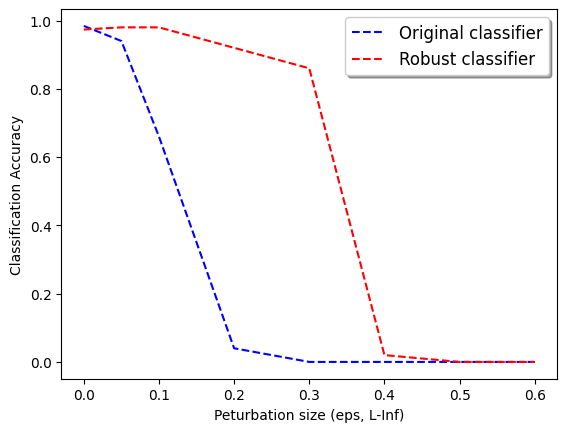

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.array(eps_range), np.array(nb_correct_original), 'b--', label='Original classifier')
ax.plot(np.array(eps_range), np.array(nb_correct_robust), 'r--', label='Robust classifier')

legend = ax.legend(loc='upper right', shadow=True, fontsize='large')

plt.xlabel('Peturbation size (eps, L-Inf)')
plt.ylabel('Classification Accuracy')
plt.show()

Running eps 0.05
Running eps 0.1
Running eps 0.2
Running eps 0.3
Running eps 0.4
Running eps 0.5
Running eps 0.6


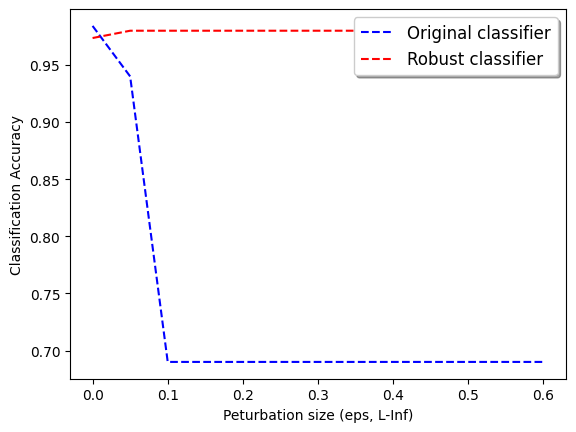

In [ ]:
#8/ What happens when we reduce the number of max_iter to 10 ? Which model becomes better?
attacker_pgd = ProjectedGradientDescent(estimator=classifier, eps=0.5, eps_step=0.01, max_iter=10, verbose=False)
attacker_robust_pgd = ProjectedGradientDescent(estimator=robust_classifier, eps=0.5, eps_step=0.01, max_iter=10, verbose=False)

eps_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
eps_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
nb_correct_original = []
nb_correct_robust = []

nb_samples = 100

for eps in eps_range:
    print("Running eps {}".format(eps))
    attacker_pgd.set_params(**{'eps': eps})
    attacker_robust_pgd.set_params(**{'eps': eps})
    x_test_adv = attacker_pgd.generate(x_test[:nb_samples], y_test[:nb_samples])
    x_test_adv_robust = attacker_robust_pgd.generate(x_test[:nb_samples], y_test[:nb_samples])

    x_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
    nb_correct_original += [np.sum(x_test_adv_pred == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples]

    x_test_adv_robust_pred = np.argmax(robust_classifier.predict(x_test_adv_robust), axis=1)
    nb_correct_robust += [np.sum(x_test_adv_robust_pred == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples]

eps_range = [0] + eps_range
nb_correct_original = [nb_correct_pred / 10000] + nb_correct_original
nb_correct_robust = [nb_correct_robust_pred / 10000] + nb_correct_robust

fig, ax = plt.subplots()
ax.plot(np.array(eps_range), np.array(nb_correct_original), 'b--', label='Original classifier')
ax.plot(np.array(eps_range), np.array(nb_correct_robust), 'r--', label='Robust classifier')

legend = ax.legend(loc='upper right', shadow=True, fontsize='large')

plt.xlabel('Peturbation size (eps, L-Inf)')
plt.ylabel('Classification Accuracy')
plt.show()

When max_iter is set to 10, the PGD attack is weak because it does not have enough steps to find strong adversarial examples. As a result, the original model’s accuracy only drops to around 70%, while the robust model remains close to 98%. This suggests that the robust model is better under attack. However, this comparison is not very meaningful because the attack is too weak and does not fully reveal the models’ vulnerabilities. With a stronger attack (max_iter = 100), both models would lose more accuracy, and the difference in robustness would be more reliable.